# LPPL + ML Trading Signal System

End-to-end pipeline:
1. **Part A** — Single-asset LPPL exploration (original notebook, unchanged)
2. **Part B** — Multi-asset ML pipeline producing `signal / confidence / suggested_exposure / max_leverage`

**Runtime note (Part B):** LPPL nested-fit computation takes ~90 min per asset × 3 window scales.
Results are cached to `.pkl` files. Set `CACHE_DIR` to a Google Drive path to survive Colab session resets:
```python
from google.colab import drive
drive.mount('/content/drive')
CACHE_DIR = '/content/drive/MyDrive/lppl_cache'
```

In [1]:
!pip install lppls yfinance xgboost scikit-learn ta hmmlearn --quiet

---
## Part A — Single-Asset LPPL Exploration

Loads one CSV file, fits a single LPPL model, then runs nested window fits
to produce per-day bubble confidence scores. Set `TEST_FILE_NAME` to your ticker.
The CSV must have columns: `date` (dd/mm/yyyy) or `dateTime` (dd/mm/yyyy HH:MM),
`open`, `high`, `low`, `close`, `volume`.

In [2]:
from lppls import lppls
import numpy as np
import pandas as pd
from datetime import datetime as dt
from matplotlib import pyplot as plt
import re
import os


In [63]:
TEST_FILE_NAME = "NVDA_"  # change to your CSV filename (without .csv)
data = pd.read_csv(f"{TEST_FILE_NAME}.csv")


In [64]:
# Delete any previous output files so we start clean
for file in os.listdir('./'):
    if 'output' in file:
        os.remove(file)
        print(f'Deleted {file}')


In [65]:
def check_date_format(date_str):
    return bool(re.match(r'^\d{2}/\d{2}/\d{4}$', date_str))

def check_datetime_format(datetime_str):
    return bool(re.match(r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$', datetime_str))

date_text = 'date'
if 'date' in data.columns:
    if data['date'].apply(check_date_format).all():
        data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')
    time = [pd.Timestamp.toordinal(dt.strptime(t1, '%Y-%m-%d')) for t1 in data['date']]
elif 'dateTime' in data.columns:
    date_text = 'dateTime'
    if data['dateTime'].apply(check_datetime_format).all():
        data['dateTime'] = pd.to_datetime(data['dateTime'], format='%d/%m/%Y %H:%M').dt.strftime('%Y-%m-%d %H:%M')
    time = [pd.Timestamp.toordinal(dt.strptime(t1.split()[0], '%Y-%m-%d')) for t1 in data['dateTime']]

data.head()


,date,open,high,low,close
0,2021-05-11,13.82,14.35,13.75,14.31
1,2021-05-12,14.01,14.26,13.71,13.76
2,2021-05-13,14.03,14.08,13.46,13.67
3,2021-05-14,13.89,14.33,13.75,14.24
4,2021-05-17,14.16,14.17,13.85,14.17


In [66]:
price = np.log(data['close'].values)
observations = np.array([time, price])
MAX_SEARCHES = 25
lppls_model = lppls.LPPLS(observations=observations)
tc, m, w, a, b, c, c1, c2, O, D = lppls_model.fit(MAX_SEARCHES)


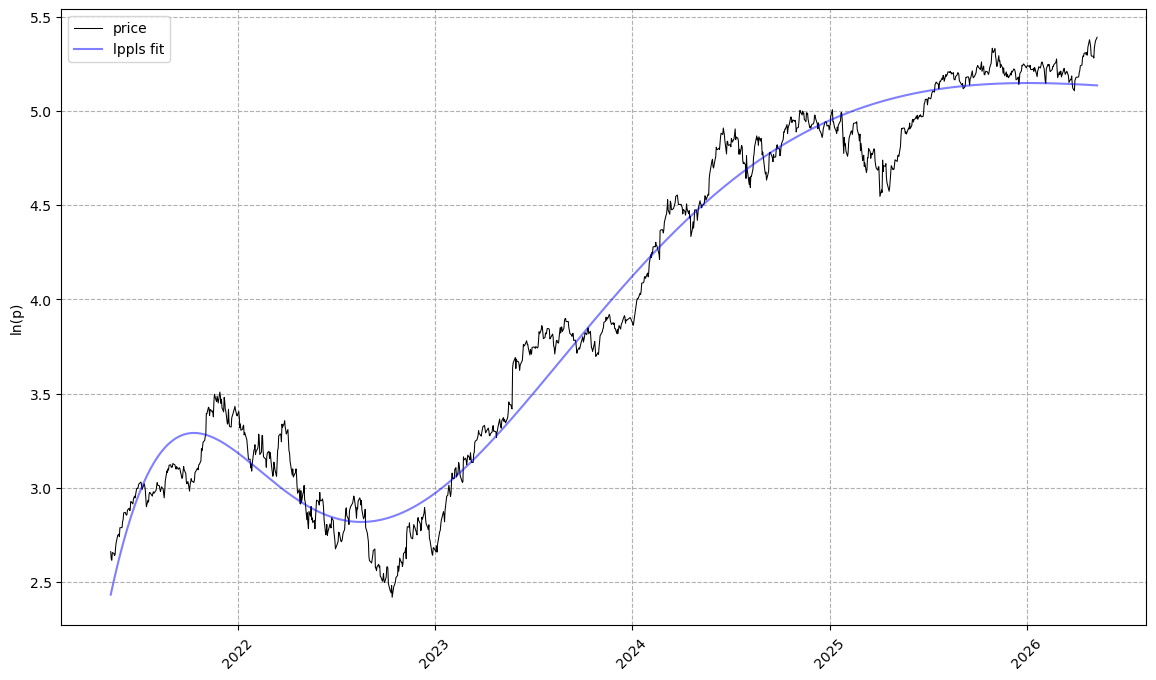

<Figure size 640x480 with 0 Axes>

In [67]:
# Plot price vs single LPPL fit
time_ord = [pd.Timestamp.fromordinal(d) for d in lppls_model.observations[0, :].astype('int32')]
t_obs    = lppls_model.observations[0, :]
lppls_fit = [lppls_model.lppls(t, tc, m, w, a, b, c1, c2) for t in t_obs]
price_obs = lppls_model.observations[1, :]

fig, ax1 = plt.subplots(figsize=(14, 8))
ax1.plot(time_ord, price_obs, label='price', color='black', linewidth=0.75)
ax1.plot(time_ord, lppls_fit,  label='lppls fit', color='blue', alpha=0.5)
ax1.grid(which='major', axis='both', linestyle='--')
ax1.set_ylabel('ln(p)')
ax1.legend(loc=2)
plt.xticks(rotation=45)
plt.show()
plt.clf()


In [68]:
# Nested window fits — produces bubble confidence per day
# NOTE: this cell can take 20-30 minutes on a single asset
res = lppls_model.mp_compute_nested_fits(
    workers=8,
    window_size=120,
    smallest_window_size=30,
    outer_increment=1,
    inner_increment=5,
    max_searches=MAX_SEARCHES
)


  0%|          | 0/1137 [00:00<?, ?it/s]

100%|██████████| 1137/1137 [02:25<00:00,  7.79it/s]


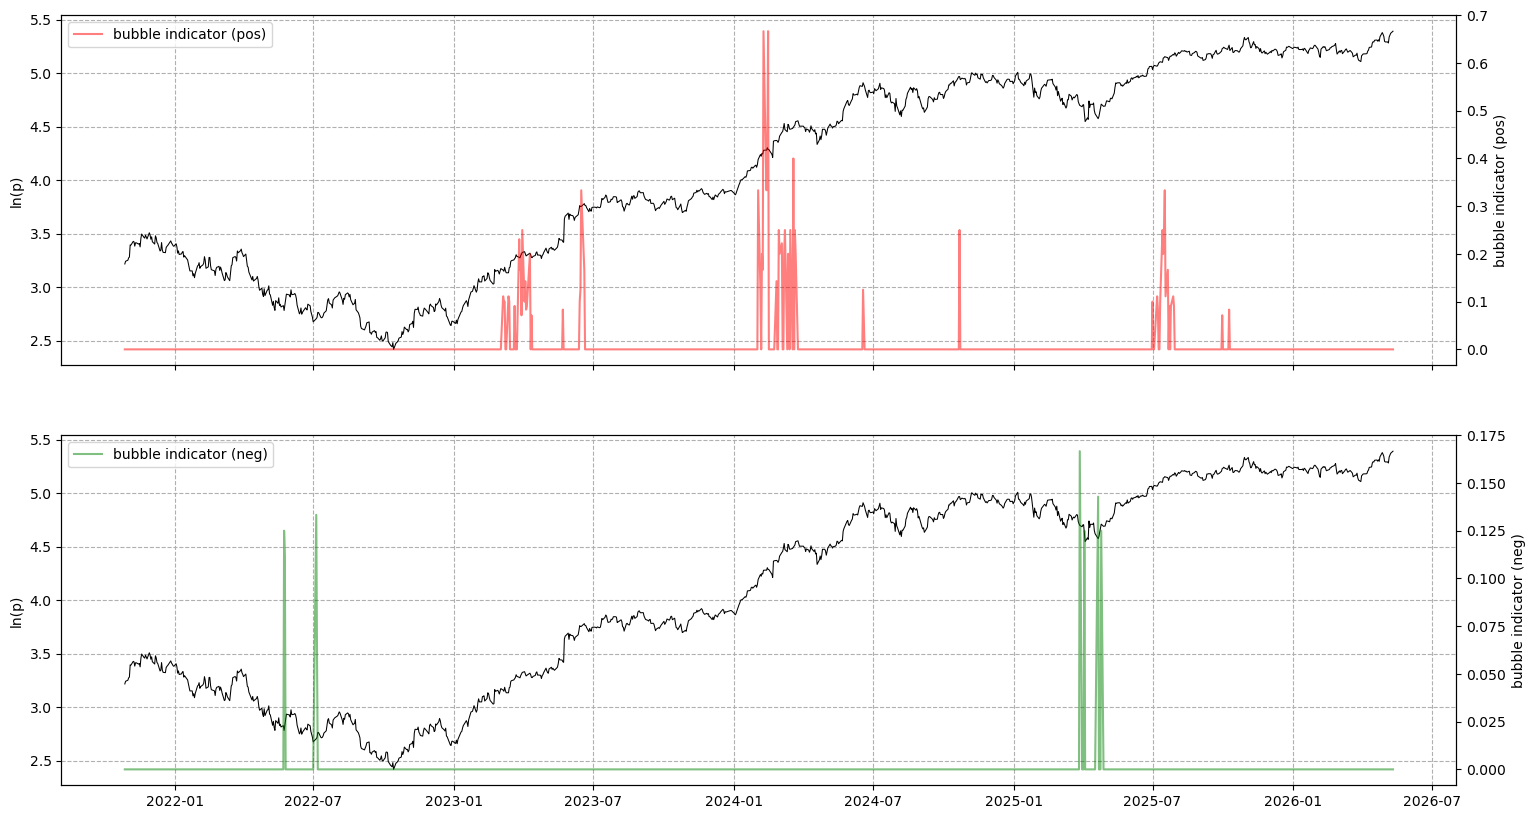

<Figure size 640x480 with 0 Axes>

In [69]:
res_df = lppls_model.compute_indicators(res)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))

ts = [pd.Timestamp.fromordinal(d) for d in res_df['time'].astype('int32')]

ax1_0 = ax1.twinx()
ax1.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax1_0.plot(ts, res_df['pos_conf'], label='bubble indicator (pos)', color='red', alpha=0.5)

ax2_0 = ax2.twinx()
ax2.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax2_0.plot(ts, res_df['neg_conf'], label='bubble indicator (neg)', color='green', alpha=0.5)

for ax in (ax1, ax2):
    ax.grid(which='major', axis='both', linestyle='--')
    ax.set_ylabel('ln(p)')
ax1_0.set_ylabel('bubble indicator (pos)'); ax1_0.legend(loc=2)
ax2_0.set_ylabel('bubble indicator (neg)'); ax2_0.legend(loc=2)
plt.xticks(rotation=45)
plt.show()
plt.clf()


In [70]:
# Align LPPL indicators with original data and save output CSV
row_diff     = len(data) - len(res_df)
pos_conf_arr = [0.0] * row_diff + list(res_df['pos_conf'].values)
neg_conf_arr = [0.0] * row_diff + list(res_df['neg_conf'].values)
data['bubble_pos_conf'] = pos_conf_arr
data['bubble_neg_conf'] = neg_conf_arr
if date_text in data.columns:
    data.set_index(date_text, inplace=True)
data.to_csv(f'output{TEST_FILE_NAME}.csv')
data.head()

,open,high,low,close,bubble_pos_conf,bubble_neg_conf
date,,,,,,
2021-05-11,13.82,14.35,13.75,14.31,0.0,0.0
2021-05-12,14.01,14.26,13.71,13.76,0.0,0.0
2021-05-13,14.03,14.08,13.46,13.67,0.0,0.0
2021-05-14,13.89,14.33,13.75,14.24,0.0,0.0
2021-05-17,14.16,14.17,13.85,14.17,0.0,0.0


---
## Part B — Multi-Asset ML Trading Signal System (Aggressive · Regime-Aware · Stateful)

Pipeline: yfinance OHLCV → multi-scale LPPL → annually-refit HMM regimes →
29-feature matrix → walk-forward XGBoost → **stateful position machine** with
regime damping.

### Position state machine

| State | Position | Entry trigger | Exit trigger |
|---|---|---|---|
| `UNLEV_LONG` | **+1× baseline** (default) | (initial / fallback) | buy → `LEV_LONG`, sell → `SHORT` |
| `LEV_LONG`   | sized at entry, up to **+12×** × regime damp | `signal == buy` | After `LEV_HOLD_DAYS` (default **5 days**) → `UNLEV_LONG`. Sell → `SHORT` immediately. New buy refreshes size + timer. |
| `SHORT`      | sized at entry, down to **−6×** × regime damp | `signal == sell` | `p_buy ≥ SHORT_EXIT_PBUY` (default **0.30**) → `UNLEV_LONG` (or `LEV_LONG` if that day's argmax is buy) |

**Holding semantics:** position size is captured at state entry (using that
day's edge and regime damping) and held constant through the state — leveraged
longs degrade to baseline after a short holding window, while shorts hold their
entry size until the **slightest** upward signal lifts `p_buy` over the
threshold.

### Regime damping (applied at state entry)

| Regime | Sharpe ranking | Damping on caps |
|---|---|---|
| `regime_0` | worst (bear / high-vol) | × **0.35** |
| `regime_1` | middle | × **0.75** |
| `regime_2` | best (bull / low-vol) | × **1.00** |

### Tunable knobs (cell `04cb4fcb`)

`MAX_LEVERAGE=12`, `SHORT_CAP=6`, `CONF_FLOOR=0.5`, `LEV_HOLD_DAYS=5`,
`SHORT_EXIT_PBUY=0.30`, plus the `REGIME_DAMP` table.

### Output columns

| Output | Example |
|--------|---------|
| Signal | `buy` / `sell` / `hold` |
| Confidence | `0.76` |
| Regime | `0` / `1` / `2` (or `-1` if pre-warmup) |
| State | `UNLEV_LONG` / `LEV_LONG` / `SHORT` |
| Target Position | `4.5` (4.5× long) or `-2.3` (2.3× short) |
| Max Leverage | `4.5` (= \|target_position\|) |

In [3]:
import yfinance as yf
import pickle

# ── Configuration — edit these values ─────────────────────────────────────
TICKERS   = ['NVDA', 'AAPL', 'MSFT', 'AMD', 'TSLA', 'SPY', 'QQQ', 'BTC-USD']
START     = '2010-01-01'   # 15 years of daily data
END       = '2025-12-31'
CACHE_DIR = '.'            # notebook runs from project_files/, so '.' = same folder as the .pkl files. Use '/content/drive/MyDrive/lppl_cache' for Colab+Drive.
os.makedirs(CACHE_DIR, exist_ok=True)

# Download all tickers one-by-one to avoid multi-level column issues
asset_data = {}
for ticker in TICKERS:
    print(f'Downloading {ticker}...')
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    df.columns = ['open','high','low','close','volume']
    df = df.dropna()
    asset_data[ticker] = df
    print(f'  {ticker}: {len(df)} rows  ({df.index[0].date()} to {df.index[-1].date()})')

print(f'\nLoaded {len(asset_data)} tickers: {list(asset_data.keys())}')

  NVDA: 4023 rows  (2010-01-04 to 2025-12-30)
  AAPL: 4023 rows  (2010-01-04 to 2025-12-30)
  MSFT: 4023 rows  (2010-01-04 to 2025-12-30)
  AMD: 4023 rows  (2010-01-04 to 2025-12-30)
  TSLA: 3901 rows  (2010-06-29 to 2025-12-30)
  SPY: 4023 rows  (2010-01-04 to 2025-12-30)
  QQQ: 4023 rows  (2010-01-04 to 2025-12-30)
  BTC-USD: 4123 rows  (2014-09-17 to 2025-12-30)

Loaded 8 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMD', 'TSLA', 'SPY', 'QQQ', 'BTC-USD']


In [4]:
# ── FAST LOAD: Load pre-computed LPPL from same folder as notebook (skip expensive computation) ────
import pickle
import os

CACHE_DIR = '.'  # notebook runs from project_files/, so '.' is where the .pkl files live
MAX_SEARCHES = 25

lppl_cache = {}
for ticker in TICKERS:
    cache_path = os.path.join(CACHE_DIR, f'lppl_{ticker}.pkl')
    if os.path.exists(cache_path):
        print(f'Loading cached LPPL for {ticker}...')
        with open(cache_path, 'rb') as fh:
            lppl_cache[ticker] = pickle.load(fh)
    else:
        print(f'ERROR: {cache_path} not found. Make sure .pkl files exist next to the notebook.')

print(f'\nLoaded LPPL cache for {len(lppl_cache)} tickers')
for ticker, scales in lppl_cache.items():
    print(f'  {ticker}: {list(scales.keys())}')

Loading cached LPPL for NVDA...
Loading cached LPPL for AAPL...
Loading cached LPPL for MSFT...
Loading cached LPPL for AMD...
Loading cached LPPL for TSLA...
Loading cached LPPL for SPY...
Loading cached LPPL for QQQ...
Loading cached LPPL for BTC-USD...

Loaded LPPL cache for 8 tickers
  NVDA: ['short', 'mid', 'long']
  AAPL: ['short', 'mid', 'long']
  MSFT: ['short', 'mid', 'long']
  AMD: ['short', 'mid', 'long']
  TSLA: ['short', 'mid', 'long']
  SPY: ['short', 'mid', 'long']
  QQQ: ['short', 'mid', 'long']
  BTC-USD: ['short', 'mid', 'long']


In [5]:
def build_asset_df(ticker, ohlcv_df, lppl_results):
    """Joins multi-scale LPPL confidence columns onto the OHLCV DataFrame."""
    df = ohlcv_df.copy()
    df['ticker'] = ticker
    for scale, rdf in lppl_results.items():
        r = rdf.copy()
        r.index = pd.to_datetime(r['time'].astype(int).apply(pd.Timestamp.fromordinal))
        df[f'pos_conf_{scale}'] = r['pos_conf'].reindex(df.index, fill_value=0.0)
        df[f'neg_conf_{scale}'] = r['neg_conf'].reindex(df.index, fill_value=0.0)
    return df

merged   = {t: build_asset_df(t, asset_data[t], lppl_cache[t]) for t in TICKERS}
all_data = pd.concat(merged.values(), axis=0).sort_index()
print(f'Total rows across all assets: {len(all_data)}')


Total rows across all assets: 32162


In [6]:
# ── Annual-refit HMM regime detector (per-asset) ──────────────────────────
# Each January, fit a Gaussian HMM on the prior N years of (log_return, 20d_vol)
# for that ticker, then label every day in the new year with its regime.
# Regimes are re-ordered by Sharpe-proxy (mean_ret / mean_vol) so regime_0 = worst,
# regime_{N-1} = best — keeps regime IDs comparable across years and assets.
from hmmlearn.hmm import GaussianHMM

N_REGIMES         = 3       # latent regimes (worst / middle / best by Sharpe-proxy)
HMM_LOOKBACK_YRS  = 5       # max years of history per annual refit
HMM_MIN_TRAIN_YRS = 2       # don't refit if fewer years of history available

def fit_regimes_per_asset(ohlcv_df,
                          n_regimes=N_REGIMES,
                          lookback=HMM_LOOKBACK_YRS,
                          min_train=HMM_MIN_TRAIN_YRS):
    df = ohlcv_df.copy().sort_index()
    df['log_ret']  = np.log(df['close']).diff()
    df['vol_20d_hmm'] = df['log_ret'].rolling(20).std() * np.sqrt(252)
    df = df.dropna(subset=['log_ret', 'vol_20d_hmm'])

    out = pd.DataFrame(index=df.index)
    out['regime'] = np.nan
    for i in range(n_regimes):
        out[f'regime_{i}_prob'] = np.nan

    for y in sorted(df.index.year.unique()):
        train = df[(df.index.year >= y - lookback) & (df.index.year < y)]
        test  = df[df.index.year == y]
        if train.index.year.nunique() < min_train or len(test) == 0:
            continue
        X_train = train[['log_ret', 'vol_20d_hmm']].values
        X_test  = test[['log_ret', 'vol_20d_hmm']].values
        try:
            hmm = GaussianHMM(n_components=n_regimes, covariance_type='full',
                              n_iter=100, random_state=42)
            hmm.fit(X_train)
            # Canonical ordering: rank states by Sharpe-proxy of their emission mean
            sharpe_proxy = hmm.means_[:, 0] / (np.abs(hmm.means_[:, 1]) + 1e-9)
            order = np.argsort(sharpe_proxy)              # ascending: worst → best
            remap = {orig: new for new, orig in enumerate(order)}

            raw_labels = hmm.predict(X_test)
            raw_probs  = hmm.predict_proba(X_test)
            labels = np.array([remap[l] for l in raw_labels])
            probs  = np.zeros_like(raw_probs)
            for orig, new in remap.items():
                probs[:, new] = raw_probs[:, orig]

            out.loc[test.index, 'regime'] = labels
            for i in range(n_regimes):
                out.loc[test.index, f'regime_{i}_prob'] = probs[:, i]
        except Exception as e:
            print(f'  HMM fit failed for year {y}: {e}')
    return out

print(f'Fitting annual-refit HMMs per asset ({N_REGIMES} regimes, {HMM_LOOKBACK_YRS}yr lookback)...')
regime_results = {}
for ticker, df in merged.items():
    r = fit_regimes_per_asset(df)
    regime_results[ticker] = r
    n_class = int(r['regime'].notna().sum())
    print(f'  {ticker}: {n_class} days classified')

# Attach regime columns onto each ticker's frame so they flow into the feature step
for ticker in TICKERS:
    merged[ticker] = merged[ticker].join(regime_results[ticker])

# Sanity: pooled regime distribution
pooled = pd.concat([r['regime'] for r in regime_results.values()]).dropna().astype(int)
print('\nPooled regime distribution (across all assets / years):')
print(pooled.value_counts().sort_index().rename(lambda i: f'regime_{i}'))

Fitting annual-refit HMMs per asset (3 regimes, 5yr lookback)...


c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

  NVDA: 3519 days classified


c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

  AAPL: 3519 days classified


...

  SPY: 3519 days classified


c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

  QQQ: 3519 days classified


c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Grigo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

  BTC-USD: 3652 days classified

Pooled regime distribution (across all assets / years):
regime
regime_0     8194
regime_1    11328
regime_2     8763
Name: count, dtype: int64


In [7]:
import ta

def add_features(df):
    df = df.copy().sort_index()

    # Multi-scale LPPL derived features
    for scale in ['short', 'mid', 'long']:
        p = f'pos_conf_{scale}'
        n = f'neg_conf_{scale}'
        df[f'net_conf_{scale}']  = df[p] - df[n]         # net bubble direction
        df[f'conf_mom_{scale}']  = df[p].diff(5)          # signal acceleration
        df[f'pos_roll5_{scale}'] = df[p].rolling(5).mean() # smoothed signal

    # Cross-scale agreement flags (all three scales bullish/bearish simultaneously)
    df['scale_agree_bull'] = (
        (df['pos_conf_short'] > 0.1) & (df['pos_conf_mid'] > 0.1) & (df['pos_conf_long'] > 0.1)
    ).astype(int)
    df['scale_agree_bear'] = (
        (df['neg_conf_short'] > 0.1) & (df['neg_conf_mid'] > 0.1) & (df['neg_conf_long'] > 0.1)
    ).astype(int)

    # Return and volatility features
    df['ret_1d']   = df['close'].pct_change(1)
    df['ret_5d']   = df['close'].pct_change(5)
    df['ret_20d']  = df['close'].pct_change(20)
    df['vol_20d']  = df['ret_1d'].rolling(20).std() * np.sqrt(252)

    # Technical indicators
    df['rsi_14']   = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
    df['macd']     = ta.trend.MACD(df['close']).macd_diff()
    df['bb_pct']   = ta.volatility.BollingerBands(df['close']).bollinger_pband()
    df['atr_14']   = ta.volatility.AverageTrueRange(
                         df['high'], df['low'], df['close'], window=14).average_true_range()
    df['vol_ratio'] = df['volume'] / df['volume'].rolling(20).mean()

    return df

# Apply per-ticker to avoid rolling contamination across assets
featured = pd.concat([add_features(merged[t]) for t in TICKERS], axis=0).sort_index()

FEATURE_COLS = [
    'pos_conf_short', 'neg_conf_short',
    'pos_conf_mid',   'neg_conf_mid',
    'pos_conf_long',  'neg_conf_long',
    'net_conf_short', 'net_conf_mid',   'net_conf_long',
    'conf_mom_short', 'conf_mom_mid',   'conf_mom_long',
    'pos_roll5_short','pos_roll5_mid',  'pos_roll5_long',
    'scale_agree_bull', 'scale_agree_bear',
    'ret_1d', 'ret_5d', 'ret_20d', 'vol_20d',
    'rsi_14', 'macd', 'bb_pct', 'atr_14', 'vol_ratio',
    # HMM regime probabilities (joined in upstream from regime_results)
    'regime_0_prob', 'regime_1_prob', 'regime_2_prob',
]
featured = featured.dropna(subset=FEATURE_COLS)
print(f'Feature matrix: {len(featured)} rows x {len(FEATURE_COLS)} features')

Feature matrix: 28285 rows x 29 features


In [8]:
# ── Tunable: adjust horizon and thresholds to match your trading style ────
HORIZON     = 30      # trading days ahead for forward return
BUY_THRESH  =  0.01   # +1% -> BUY label
SELL_THRESH = -0.01   # -1% -> SELL label

def add_labels(df):
    df = df.copy().sort_index()
    df['forward_ret'] = df['close'].pct_change(HORIZON).shift(-HORIZON)
    return df

# Compute labels per ticker to avoid look-ahead across asset boundaries
featured = pd.concat(
    [add_labels(featured[featured['ticker'] == t]) for t in TICKERS]
).sort_index()
featured = featured.dropna(subset=['forward_ret'])

featured['target'] = featured['forward_ret'].apply(
    lambda r: 2 if r > BUY_THRESH else (0 if r < SELL_THRESH else 1)
)  # 0=sell  1=hold  2=buy

print(featured['target'].value_counts().rename({0: 'sell', 1: 'hold', 2: 'buy'}))

target
buy     16563
sell     9245
hold     2237
Name: count, dtype: int64


In [9]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

# ── Walk-forward parameters ────────────────────────────────────────────────
TRAIN_DAYS = 1500   # ~6 years of trading days per training window
TEST_STEP  = 60     # retrain every 60 trading days (~3 months)

featured  = featured.sort_index()
dates_all = featured.index.unique().sort_values()

all_records = []

for i in range(0, len(dates_all) - TRAIN_DAYS - TEST_STEP, TEST_STEP):
    train_dates = dates_all[i : i + TRAIN_DAYS]
    test_dates  = dates_all[i + TRAIN_DAYS : i + TRAIN_DAYS + TEST_STEP]

    train = featured[featured.index.isin(train_dates)]
    test  = featured[featured.index.isin(test_dates)]
    if len(train) < 100 or len(test) == 0:
        continue

    # CalibratedClassifierCV converts raw XGBoost scores into true probabilities
    base  = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss', random_state=42
    )
    model = CalibratedClassifierCV(base, method='isotonic', cv=3)
    model.fit(train[FEATURE_COLS].values, train['target'].values)

    proba = model.predict_proba(test[FEATURE_COLS].values)  # [p_sell, p_hold, p_buy]
    # Carry `regime` through so the downstream signal cell can damp aggression by regime
    rec   = test[['ticker', 'close', 'vol_20d', 'target', 'regime']].copy()
    rec[['p_sell', 'p_hold', 'p_buy']] = proba
    all_records.append(rec)

val_df = pd.concat(all_records).sort_index()
y_pred = val_df[['p_sell', 'p_hold', 'p_buy']].values.argmax(axis=1)
print(classification_report(val_df['target'], y_pred, target_names=['sell', 'hold', 'buy']))

c:\Users\Grigo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Grigo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Grigo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Grigo\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:11:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

              precision    recall  f1-score   support

        sell       0.35      0.04      0.07      6198
        hold       0.00      0.00      0.00      1309
         buy       0.59      0.96      0.73     10621

    accuracy                           0.58     18128
   macro avg       0.31      0.33      0.27     18128
weighted avg       0.46      0.58      0.45     18128



In [12]:
# ── Stateful aggressive strategy (hold-then-decay long, hold-until-uptick short) ──
# Per-ticker state machine over time:
#   UNLEV_LONG : +1× baseline (default state)
#   LEV_LONG   : +N× (sized at entry, regime-damped). Held for LEV_HOLD_DAYS days
#                then decays to UNLEV_LONG. Fresh buy signals refresh size + timer.
#   SHORT      : −M× (sized at entry, regime-damped). Held until p_buy ≥ SHORT_EXIT_PBUY
#                (the "slightest" upward signal), then exits to UNLEV_LONG
#                (or LEV_LONG if that day's argmax is buy).
# Sell signals always take priority and flip the state to SHORT immediately.

BASELINE         = 1.0
MAX_LEVERAGE     = 12.0
SHORT_CAP        = 6.0
CONF_FLOOR       = 0.5      # below this argmax probability, edge = 0 (no leverage / no short scaling)
LEV_HOLD_DAYS    = 5        # trading days to hold a leveraged long before reverting to UNLEV_LONG
SHORT_EXIT_PBUY  = 0.30     # exit short the moment p_buy crosses this — "slightest upward signal"

# Regime damping — applied at state ENTRY only (then held fixed through the state)
REGIME_DAMP = {0: 0.35, 1: 0.75, 2: 1.0}

def _edge(conf):
    return max(0.0, min(1.0, (conf - CONF_FLOOR) * 2))

def _damp(regime):
    if pd.isna(regime):
        return 1.0
    return REGIME_DAMP.get(int(regime), 1.0)

def stateful_signal_per_ticker(group):
    """Time-ordered state-machine scan for one ticker's predictions."""
    group = group.sort_index()
    state         = 'UNLEV_LONG'
    held_position = BASELINE
    lev_days_left = 0

    rows = []
    for ts, row in group.iterrows():
        p_sell, p_hold, p_buy = row['p_sell'], row['p_hold'], row['p_buy']
        probs       = [p_sell, p_hold, p_buy]
        idx         = int(np.argmax(probs))
        signal      = ['sell', 'hold', 'buy'][idx]
        confidence  = float(probs[idx])
        edge        = _edge(confidence)
        damp        = _damp(row.get('regime', np.nan))
        max_lev_eff   = MAX_LEVERAGE * damp
        short_cap_eff = SHORT_CAP    * damp

        if state == 'SHORT':
            # Hold short until the slightest hint price will rise
            if p_buy >= SHORT_EXIT_PBUY:
                if signal == 'buy':
                    state = 'LEV_LONG'
                    held_position = BASELINE + edge * (max_lev_eff - BASELINE)
                    lev_days_left = LEV_HOLD_DAYS - 1   # today counts as day 1
                else:
                    state = 'UNLEV_LONG'
                    held_position = BASELINE
                    lev_days_left = 0
            # else: stay SHORT, position unchanged
        else:
            # Not currently short — sell takes priority, then buy, then hold-decay
            if signal == 'sell':
                state = 'SHORT'
                held_position = BASELINE - edge * (BASELINE + short_cap_eff)
                lev_days_left = 0
            elif signal == 'buy':
                state = 'LEV_LONG'
                held_position = BASELINE + edge * (max_lev_eff - BASELINE)
                lev_days_left = LEV_HOLD_DAYS - 1
            else:  # hold
                if state == 'LEV_LONG':
                    lev_days_left -= 1
                    if lev_days_left < 0:
                        state = 'UNLEV_LONG'
                        held_position = BASELINE
                    # else: keep held_position from the original buy
                else:
                    state = 'UNLEV_LONG'
                    held_position = BASELINE

        rows.append({
            'signal'         : signal,
            'confidence'     : round(confidence, 4),
            'state'          : state,
            'target_position': round(held_position, 4),
            'max_leverage'   : round(abs(held_position), 2),
        })
    return pd.DataFrame(rows, index=group.index)

# Drop any prior copies of these columns before re-generating
for col in ['signal', 'confidence', 'state', 'target_position', 'max_leverage']:
    if col in val_df.columns:
        val_df = val_df.drop(columns=col)

val_df = val_df.sort_index()
sig_df = val_df.groupby('ticker', group_keys=False).apply(stateful_signal_per_ticker)
val_df = pd.concat([val_df, sig_df], axis=1)

# Most recent state + position for every ticker
latest = val_df.groupby('ticker')[['signal', 'confidence', 'regime', 'state',
                                    'target_position', 'max_leverage']].last()
print(latest.to_string())

# How much time the portfolio spends in each state (informational)
print('\nState distribution across all (ticker, day) rows:')
print(val_df['state'].value_counts().to_string())
print(f'\nMean position: {val_df["target_position"].mean():.2f}x'
      f'   |   Range: {val_df["target_position"].min():.2f}x to {val_df["target_position"].max():.2f}x')

        signal  confidence  regime       state  target_position  max_leverage
ticker                                                                       
AAPL      sell      0.4875     2.0  UNLEV_LONG           1.0000          1.00
AMD        buy      0.5327     1.0    LEV_LONG           1.2094          1.21
BTC-USD    buy      0.5134     2.0    LEV_LONG           1.2947          1.29
MSFT       buy      0.4819     1.0    LEV_LONG           1.0000          1.00
NVDA       buy      0.4864     0.0    LEV_LONG           1.0000          1.00
QQQ        buy      0.5104     0.0    LEV_LONG           1.0664          1.07
SPY        buy      0.4808     2.0    LEV_LONG           1.0000          1.00
TSLA       buy      0.5405     0.0    LEV_LONG           1.8919          1.89

State distribution across all (ticker, day) rows:
state
LEV_LONG      17393
SHORT           451
UNLEV_LONG      284

Mean position: 2.38x   |   Range: -1.33x to 8.21x


C:\Users\Grigo\AppData\Local\Temp\ipykernel_23272\1187606642.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sig_df = val_df.groupby('ticker', group_keys=False).apply(stateful_signal_per_ticker)


Sharpe:           0.95
Max drawdown:     -95.8%
Total return:     223.92x  (vs B&H 103.40x)
Avg position:     2.38x
Position range:   -1.33x  to  8.21x
Time long / flat / short: 99.9% / 0.0% / 0.1%


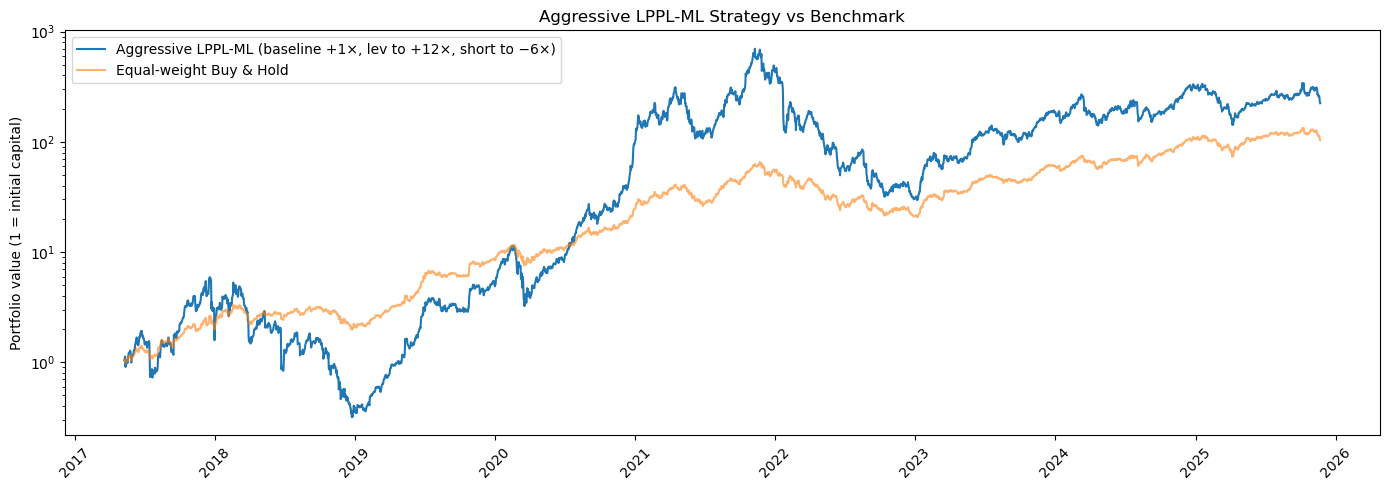

In [13]:
# ── Backtest: aggressive strategy with fully-invested baseline (+1×) ──────
# Default state is +1× long; buy signals lever up (toward +12×), sell signals flip short (toward −6×).
val_df = val_df.sort_index()
val_df['ret_1d_actual'] = val_df.groupby('ticker')['close'].pct_change(1)

# Strategy return = target_position × asset return (signed exposure, no masking)
val_df['strat_ret'] = val_df['target_position'] * val_df['ret_1d_actual']

# Equal-weight aggregate across all tickers by date
daily   = val_df.groupby(level=0)[['strat_ret', 'ret_1d_actual']].mean()
cum_s   = (1 + daily['strat_ret']).cumprod()
cum_bah = (1 + daily['ret_1d_actual']).cumprod()

sharpe = (daily['strat_ret'].mean() / daily['strat_ret'].std()) * np.sqrt(252)
max_dd = (cum_s / cum_s.cummax() - 1).min()

print(f'Sharpe:           {sharpe:.2f}')
print(f'Max drawdown:     {max_dd:.1%}')
print(f'Total return:     {cum_s.iloc[-1]:.2f}x  (vs B&H {cum_bah.iloc[-1]:.2f}x)')
print(f'Avg position:     {val_df["target_position"].mean():.2f}x')
print(f'Position range:   {val_df["target_position"].min():.2f}x  to  {val_df["target_position"].max():.2f}x')
print(f'Time long / flat / short: '
      f'{(val_df["target_position"] > 0).mean():.1%} / '
      f'{(val_df["target_position"] == 0).mean():.1%} / '
      f'{(val_df["target_position"] < 0).mean():.1%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cum_s.index,   cum_s.values,   label='Aggressive LPPL-ML (baseline +1×, lev to +12×, short to −6×)')
ax.plot(cum_bah.index, cum_bah.values, label='Equal-weight Buy & Hold', alpha=0.6)
ax.set_title('Aggressive LPPL-ML Strategy vs Benchmark')
ax.set_ylabel('Portfolio value (1 = initial capital)')
ax.set_yscale('log')  # large return swings under leverage compress better on a log scale
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
import os, sys; print(sys.version); print(os.getcwd())

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
c:\Users\Grigo\OneDrive\Desktop\project 2025\project_files


In [15]:
import os; os.chdir(r"C:\Users\Grigo\OneDrive\Desktop\project 2025\project_files"); print(os.getcwd()); print(sorted(f for f in os.listdir('.') if f.endswith('.pkl') or f.endswith('.csv')))

c:\Users\Grigo\OneDrive\Desktop\project 2025\project_files
['NVDA_.csv', 'lppl_AAPL.pkl', 'lppl_AMD.pkl', 'lppl_BTC-USD.pkl', 'lppl_MSFT.pkl', 'lppl_NVDA.pkl', 'lppl_QQQ.pkl', 'lppl_SPY.pkl', 'lppl_TSLA.pkl', 'outputNVDA_.csv']


In [16]:

# Drop any stale columns from the previous strategy version before re-generating
for col in ['signal', 'confidence', 'suggested_exposure', 'max_leverage', 'target_position', 'strat_ret', 'ret_1d_actual']:
    if col in val_df.columns:
        val_df = val_df.drop(columns=col)
print("val_df cols:", list(val_df.columns))
print("rows:", len(val_df))


val_df cols: ['ticker', 'close', 'vol_20d', 'target', 'regime', 'p_sell', 'p_hold', 'p_buy', 'state']
rows: 18128
